In [58]:
# Install and import necessary libraries
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
# For models
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Download VADER lexicon if not already present
nltk.download('vader_lexicon', quiet=True)

True

In [59]:
asr = pd.read_csv(r"..\AirlineScrappedReview_Processed_StandardizedRoutes.csv")

In [60]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Passanger_Name      2807 non-null   object 
 1   Route               2807 non-null   object 
 2   Rating              2807 non-null   float64
 3   Verified            2807 non-null   object 
 4   Review_title        2807 non-null   object 
 5   Review_content      2807 non-null   object 
 6   Traveller_Type      2807 non-null   object 
 7   Class               2807 non-null   object 
 8   Start_Location      2807 non-null   object 
 9   End_Location        2807 non-null   object 
 10  Layover_Route       484 non-null    object 
 11  Start_Latitude      2747 non-null   float64
 12  Start_Longitude     2747 non-null   float64
 13  Start_Address       2807 non-null   object 
 14  End_Latitude        2708 non-null   float64
 15  End_Longitude       2708 non-null   float64
 16  End_Ad

<h1>Data Cleaning</h1>

In [61]:
asr = asr[asr['Class'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Various"].reset_index(drop=True)

<h1>One Hot Encoding</h1>

In [62]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(asr[['Class', 'Traveller_Type', 'Verified']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Class', 'Traveller_Type', 'Verified']))

asr = pd.concat([asr.drop(['Class', 'Traveller_Type', 'Verified'], axis=1), one_hot_df], axis=1)
asr = asr.drop(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Verified_Not Verified', 'Route_Frequency'], axis=1)

In [63]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Passanger_Name                 2803 non-null   object 
 1   Route                          2803 non-null   object 
 2   Rating                         2803 non-null   float64
 3   Review_title                   2803 non-null   object 
 4   Review_content                 2803 non-null   object 
 5   Start_Location                 2803 non-null   object 
 6   End_Location                   2803 non-null   object 
 7   Layover_Route                  483 non-null    object 
 8   Start_Address                  2803 non-null   object 
 9   End_Address                    2803 non-null   object 
 10  Sentiment_Score                2803 non-null   float64
 11  Satisfaction                   2803 non-null   int64  
 12  Has_Layover                    2803 non-null   i

## Step 3: Feature Selection and Preparation

### Selected Features:
1. **Traveller_Type**: Type of passenger (Business, Leisure, etc.)
2. **Class**: Flight class (Economy, Business, First Class)
3. **Verified**: Whether the review is verified
4. **Sentiment_Score**: Calculated sentiment from review text (VADER compound score)
5. **Has_Layover**: Whether the flight had a layover (engineered feature)
6. **Route_Frequency**: Frequency encoding of standardized routes (how popular is this route)

### Why these features?
- **Traveller-related**: Type and Class directly indicate passenger segment
- **Flight-related**: Route popularity (frequency) and layover information capture route characteristics
- **Review-related**: Verified status and sentiment provide review quality indicators

### Route Feature Engineering:
- **Standardization**: Converted all "City1 to City2" formats to "City1-City2" for consistency
- **Frequency Encoding**: Popular routes get higher values, which may correlate with satisfaction
  - More frequent routes → Better established service
  - Less frequent routes → Potentially more issues or newer service


In [ ]:
label_encoder = LabelEncoder()
asr['Route_Standardized'] = label_encoder.fit_transform(asr['Route_Standardized'])

In [ ]:
# Select features for modeling (using Route_Frequency instead of raw Route)
feature_columns = [
    'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 'Traveller_Type_Couple Leisure',  'Traveller_Type_Solo Leisure','Class_Business Class', 'Class_Economy Class', 'Class_First Class', 'Class_Premium Economy', 'Verified_Trip Verified', 'Sentiment_Score', 'Has_Layover'
]
X = asr[feature_columns]
y = asr['Satisfaction']
print(f"\nSelected features summary:")
print(asr[feature_columns].describe())


Selected features summary:
       Traveller_Type_Business  Traveller_Type_Family Leisure  \
count              2803.000000                    2803.000000   
mean                  0.221905                       0.134499   
std                   0.415602                       0.341248   
min                   0.000000                       0.000000   
25%                   0.000000                       0.000000   
50%                   0.000000                       0.000000   
75%                   0.000000                       0.000000   
max                   1.000000                       1.000000   

       Traveller_Type_Couple Leisure  Traveller_Type_Solo Leisure  \
count                    2803.000000                  2803.000000   
mean                        0.337139                     0.306457   
std                         0.472817                     0.461104   
min                         0.000000                     0.000000   
25%                         0.000000     

In [66]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 2242
Test set size: 561

Training set target distribution:
Satisfaction
0    1269
1     973
Name: count, dtype: int64

Test set target distribution:
Satisfaction
0    317
1    244
Name: count, dtype: int64


### Model 1: Random Forest Classifier

In [67]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Training completed!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

Training Random Forest Classifier...
Training completed!

RANDOM FOREST CLASSIFIER - RESULTS

Accuracy:  0.8128
Precision: 0.7837
Recall:    0.7869
F1-Score:  0.7853

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.83      0.83       317
   Satisfied       0.78      0.79      0.79       244

    accuracy                           0.81       561
   macro avg       0.81      0.81      0.81       561
weighted avg       0.81      0.81      0.81       561



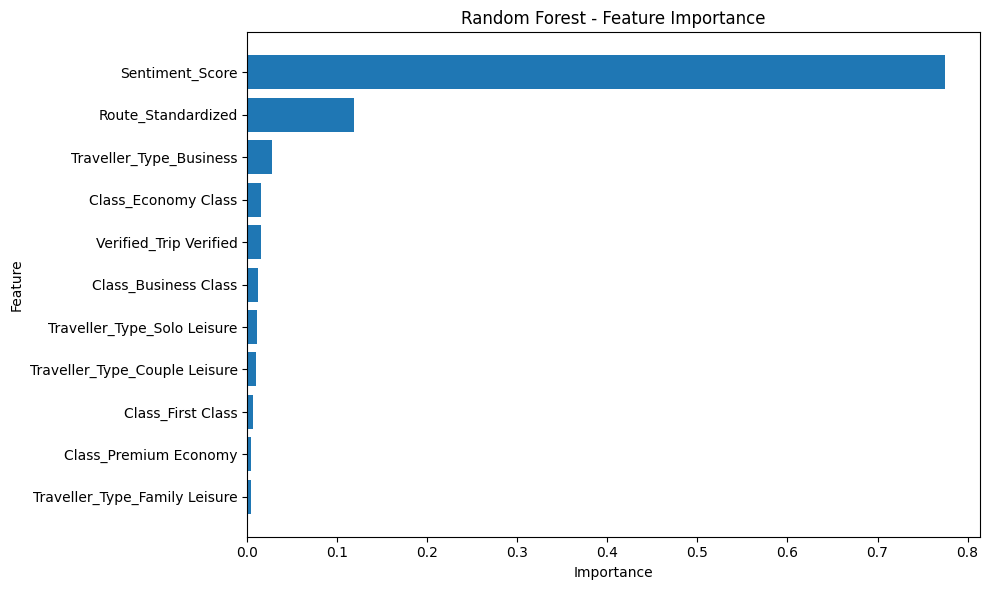


Feature Importance Rankings:
                          feature  importance
9                 Sentiment_Score    0.775072
10             Route_Standardized    0.119028
0         Traveller_Type_Business    0.027093
5             Class_Economy Class    0.015095
8          Verified_Trip Verified    0.014708
4            Class_Business Class    0.012299
3     Traveller_Type_Solo Leisure    0.011181
2   Traveller_Type_Couple Leisure    0.010197
6               Class_First Class    0.006891
7           Class_Premium Economy    0.004662
1   Traveller_Type_Family Leisure    0.003773


In [68]:
# Feature importance visualization
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance)

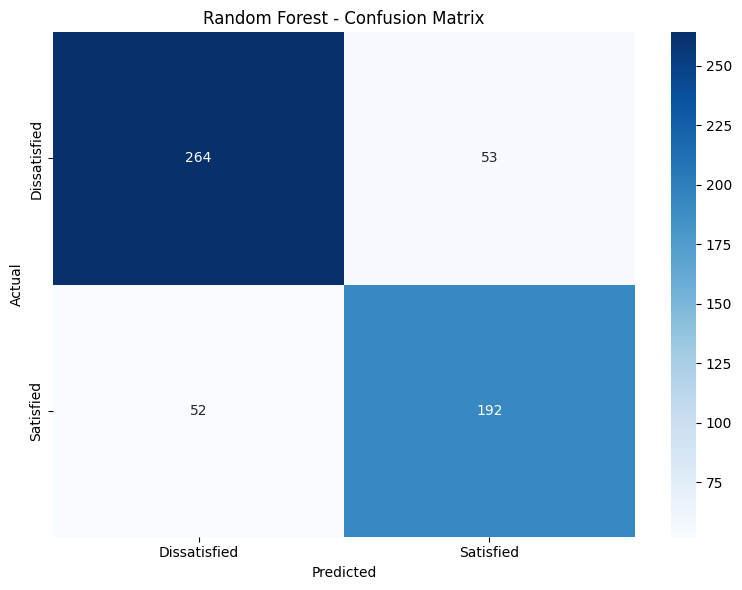

In [69]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

### Model 2: Shallow Feed-Forward Neural Network (FFNN)

In [70]:
# Scale features for neural network (important for gradient-based optimization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled for neural network training")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled for neural network training
Training data shape: (2242, 11)
Test data shape: (561, 11)


In [71]:
# Build Shallow FFNN model
print("Building Shallow Feed-Forward Neural Network...")

ffnn_model = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer with 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Second hidden layer with 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Architecture:")
ffnn_model.summary()

Building Shallow Feed-Forward Neural Network...

Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Train the FFNN model
print("Training Shallow FFNN...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training Shallow FFNN...
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6553 - loss: 0.6882 - precision_3: 0.6330 - recall_3: 0.4447 - val_accuracy: 0.7439 - val_loss: 0.6196 - val_precision_3: 0.7816 - val_recall_3: 0.6385
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7423 - loss: 0.5888 - precision_3: 0.7224 - recall_3: 0.6368 - val_accuracy: 0.7751 - val_loss: 0.5329 - val_precision_3: 0.7718 - val_recall_3: 0.7465
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7697 - loss: 0.5564 - precision_3: 0.7210 - recall_3: 0.7447 - val_accuracy: 0.8196 - val_loss: 0.5028 - val_precision_3: 0.7946 - val_recall_3: 0.8357
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7808 - loss: 0.5402 - precision_3: 0.7224 - recall_3: 0.7842 - val_accuracy: 0.8151 - val_loss: 0.4960 - val_precision_3: 0.7902 - val_recall_3: 0.8310
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7881 - loss: 0.5270 - precision_3: 0.7306 

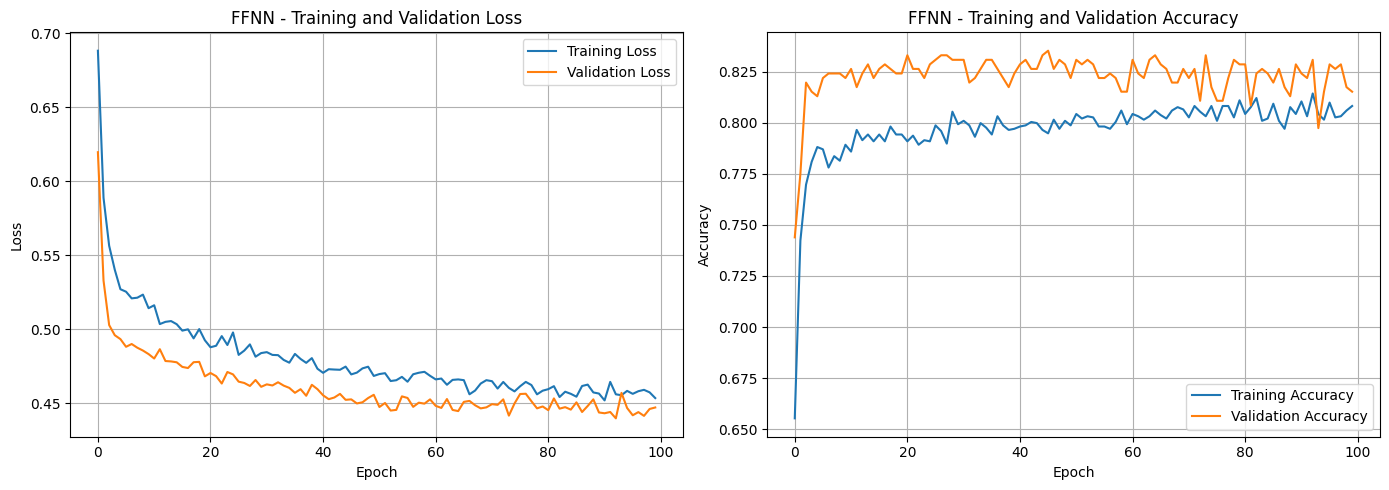

In [73]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('FFNN - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('FFNN - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [74]:
# Evaluate FFNN on test set
y_pred_ffnn_probs = ffnn_model.predict(X_test_scaled)
y_pred_ffnn = (y_pred_ffnn_probs > 0.5).astype(int).flatten()

print("="*60)
print("SHALLOW FFNN - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_ffnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ffnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ffnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ffnn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Dissatisfied', 'Satisfied']))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
SHALLOW FFNN - RESULTS

Accuracy:  0.8111
Precision: 0.7594
Recall:    0.8279
F1-Score:  0.7922

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.86      0.80      0.83       317
   Satisfied       0.76      0.83      0.79       244

    accuracy                           0.81       561
   macro avg       0.81      0.81      0.81       561
weighted avg       0.81      0.81      0.81       561



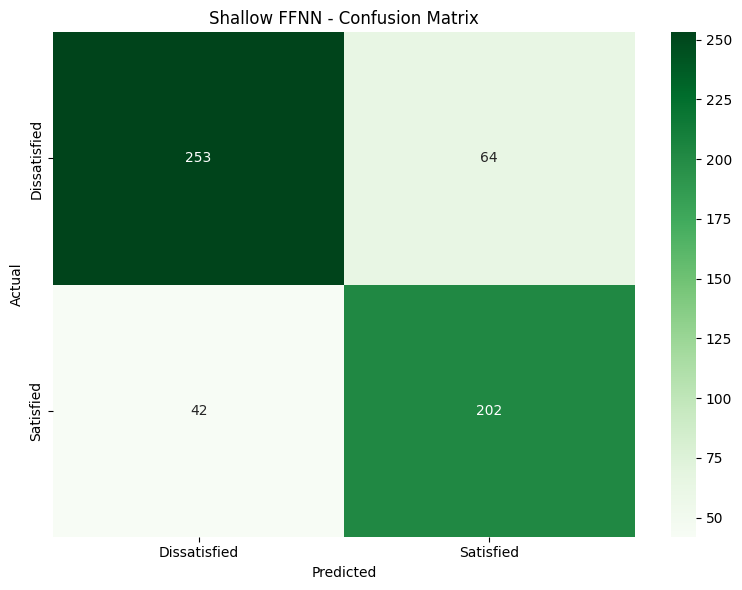

In [75]:
# Confusion Matrix for FFNN
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Shallow FFNN - Confusion Matrix')
plt.tight_layout()
plt.show()

MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.812834   0.783673 0.786885  0.785276
 Shallow FFNN  0.811052   0.759398 0.827869  0.792157


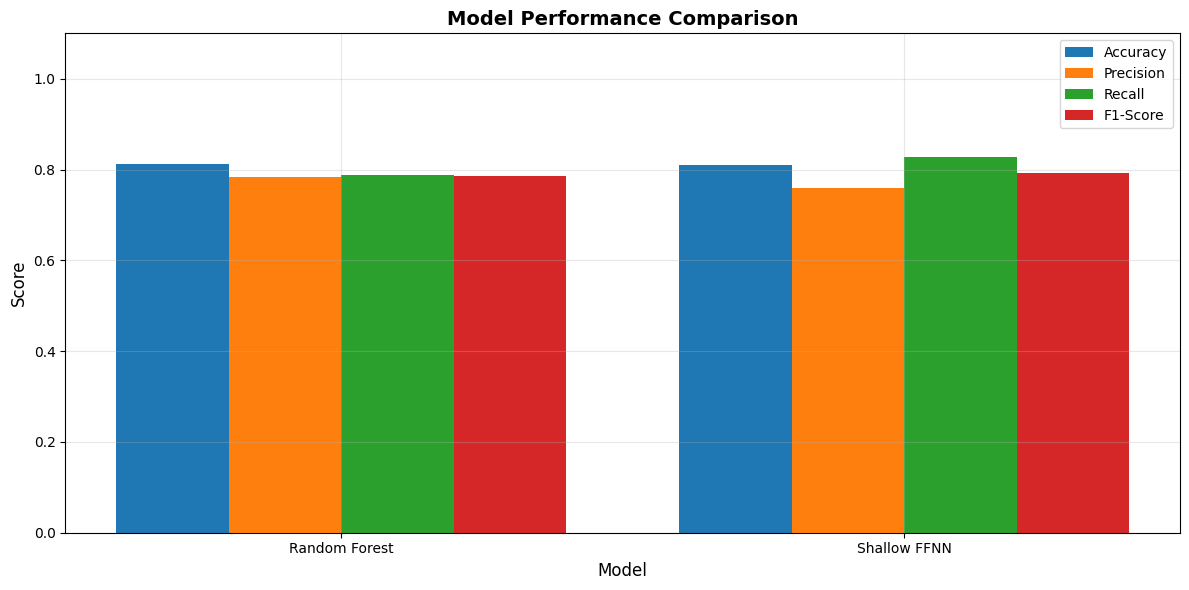

In [76]:
# Compare both models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Shallow FFNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ffnn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ffnn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ffnn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ffnn)
    ]
})

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()